## Task 4

In [7]:
import numpy as np
from scipy.sparse import coo_matrix, csc_matrix
from sksparse.cholmod import cholesky
from scipy.sparse.linalg import spsolve_triangular
import time

def my_cholesky(A):
    factor = cholesky(-A, order="natural")
    return csc_matrix(factor[0])

def task4():
        
    ## matrice sparsa
    i, j, Aij = np.loadtxt("A.txt", unpack=True)
    i = i.astype(int) # coo_matrix li vuole int
    j = j.astype(int)

    n = max(i)+1 
    A = coo_matrix((Aij, (i,j)), shape=(n,n)).tocsc()

    rhs = np.loadtxt("rhs.txt")

    ## soluzione sistema e misura tempo
    start = time.time()
    Lt = my_cholesky(A)
    end = time.time()
    tempo = end - start


    # L*y = rhs
    y = spsolve_triangular(Lt.T, rhs, lower=True)
    # Lt*x = y
    x = spsolve_triangular(Lt, y, lower=False)

    return x, tempo, Lt.nnz, A

## Task 5

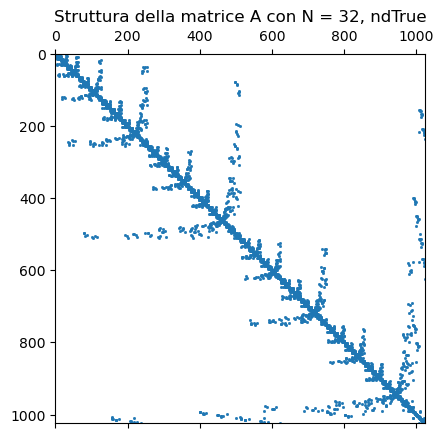

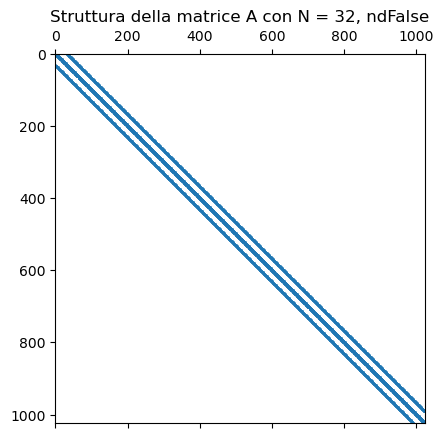

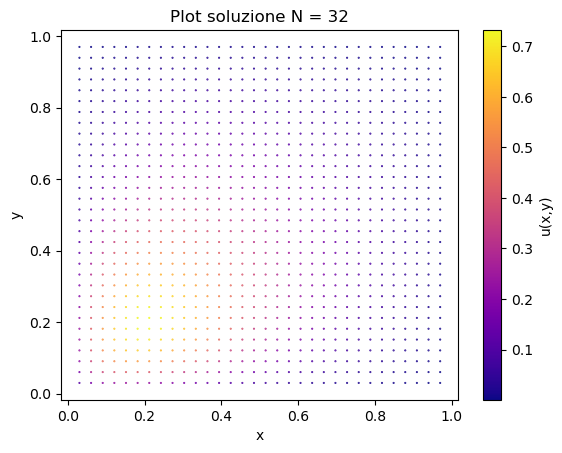

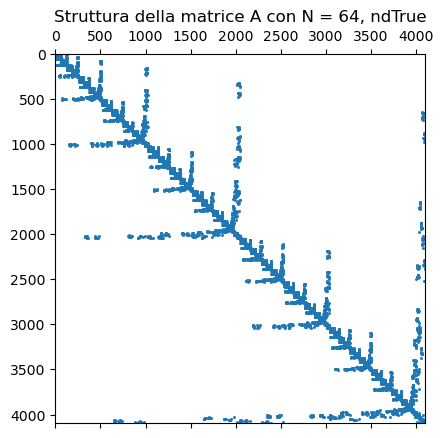

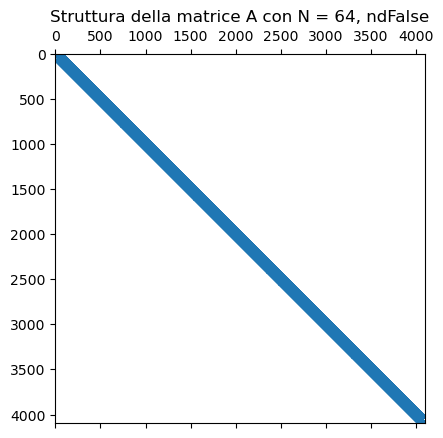

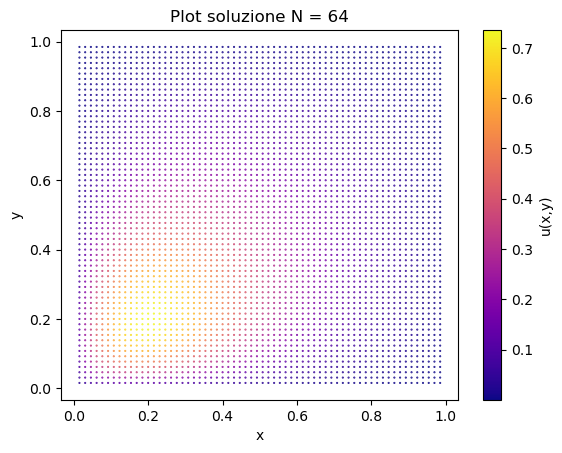

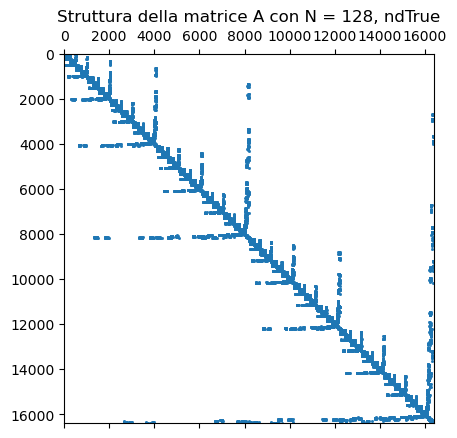

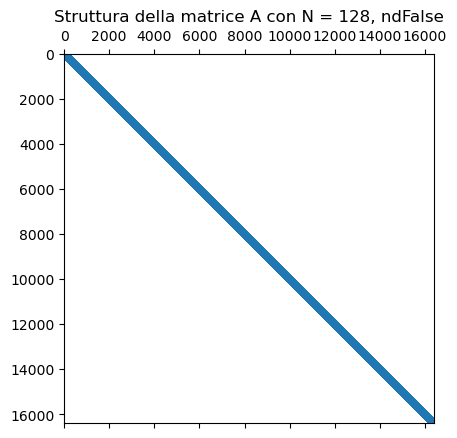

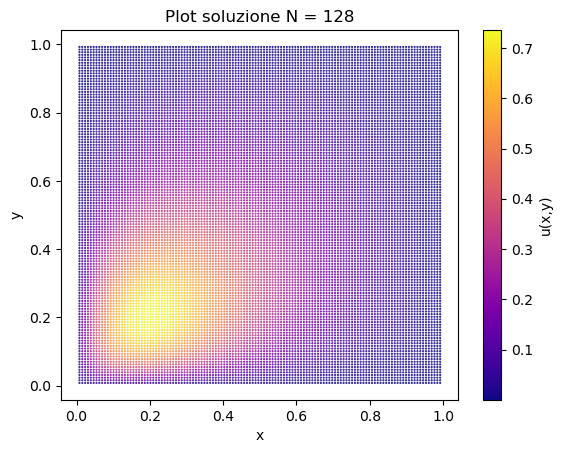

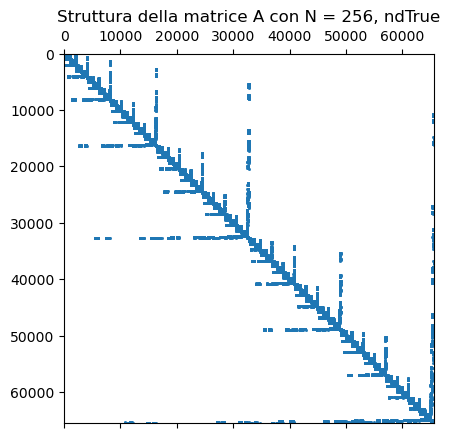

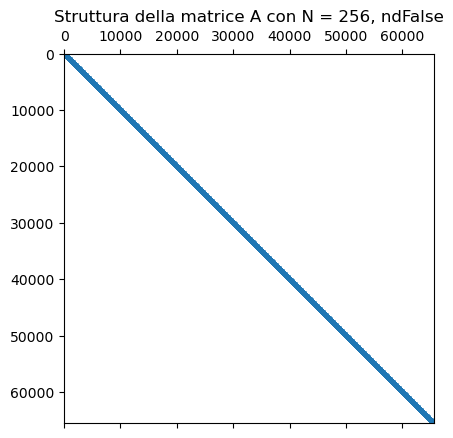

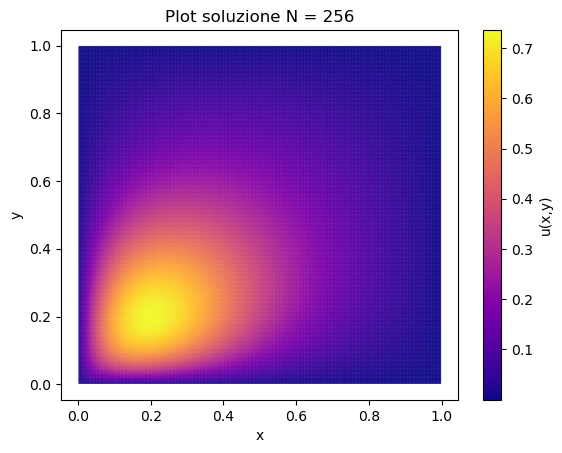

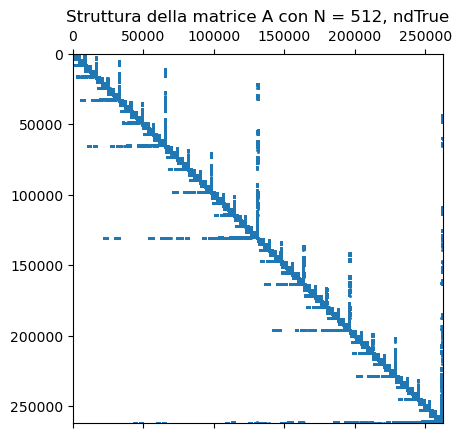

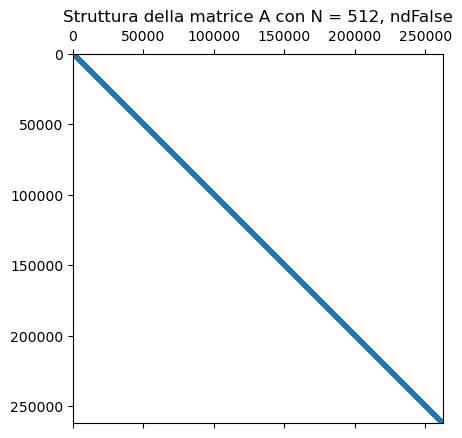

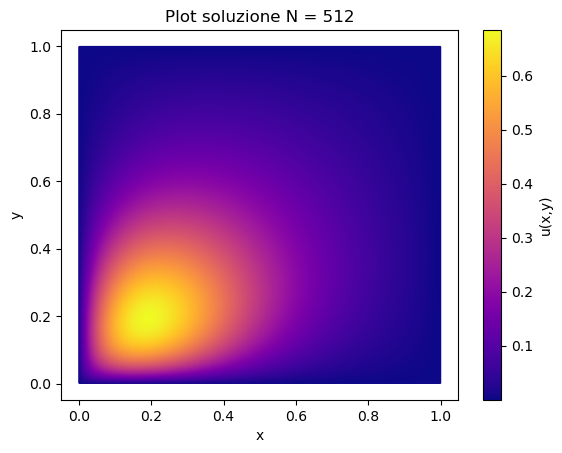

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess

dati = []

for N in [32, 64, 128, 256, 512]:
    subprocess.run(["./task1", str(N)]) # task1
    n, i, j, x_coord, y_coord = np.loadtxt("coords.txt", unpack=True) # importa griglia per plot

    subprocess.run(["./task2"]) # task2
    mmap, nmap = np.loadtxt("ordering.txt", unpack=True) # importa ordering per rimappatura output task4
    mmap = mmap.astype(int) # servono come int perché altrimenti non li accetta come indici
    nmap = nmap.astype(int) 

    for modalita in ["ndTrue", "ndFalse"]:
        subprocess.run(["./task3", str(N), modalita]) # task3

        x, tempo, nnz, A = task4() # task4
        dati.append({"N": N, "modalita": modalita, "tempo": tempo, "nnz": nnz})

        T = np.zeros(len(n)) # definisco vuoto e riempio con ordinamento giusto più tardi

        ## riordinamento x
        if modalita == "ndTrue":
            # caso ordinamento nested dissection
            for k in range(len(mmap)):
                T[nmap[k]] = x[mmap[k]]
        else: 
            # caso ordinamento naturale
            T = x
        
        ## struttura di A
        plt.figure()
        plt.spy(A, markersize=1)
        plt.title(f"Struttura della matrice A con N = {N}, {modalita}")
    
    ## plot soluzione
    plt.figure()
    plt.scatter(x_coord, y_coord, c=T, cmap="plasma", s=1, marker=".")
    plt.colorbar(label="u(x,y)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Plot soluzione N = {N}")


plt.show()
plt.close()

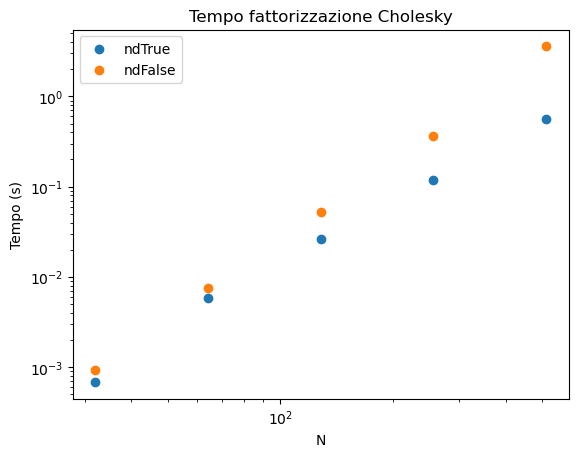

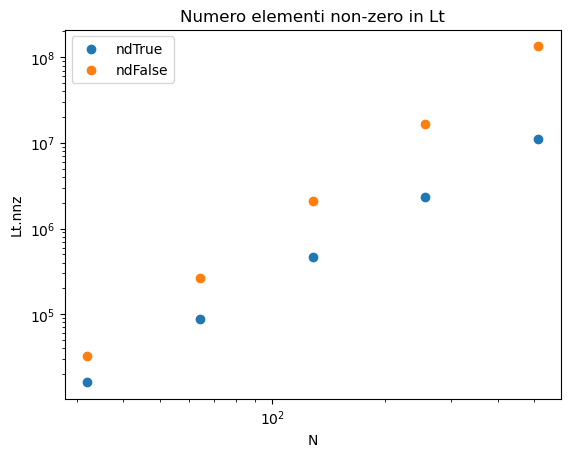

In [9]:
import matplotlib.pyplot as plt

N = [32, 64, 128, 256, 512]

tempi_nd  = [r["tempo"] for r in dati if r["modalita"] == "ndTrue"]
tempi_nat = [r["tempo"] for r in dati if r["modalita"] == "ndFalse"]
nnz_nd    = [r["nnz"]   for r in dati if r["modalita"] == "ndTrue"]
nnz_nat   = [r["nnz"]   for r in dati if r["modalita"] == "ndFalse"]

plt.figure()
plt.scatter(N, tempi_nd, marker="o", label="ndTrue")
plt.scatter(N, tempi_nat, marker="o", label="ndFalse")
plt.xlabel("N")
plt.ylabel("Tempo (s)")
plt.title("Tempo fattorizzazione Cholesky")
plt.legend()
plt.yscale("log")
plt.xscale("log")

plt.figure()
plt.scatter(N, nnz_nd,  marker='o', label="ndTrue")
plt.scatter(N, nnz_nat, marker='o', label="ndFalse")
plt.xlabel("N")
plt.ylabel("Lt.nnz")
plt.title("Numero elementi non-zero in Lt")
plt.legend()
plt.yscale("log")
plt.xscale("log")

plt.show()